In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import tkinter as tk
from tkinter import filedialog, ttk

In [2]:
input_dir = "test-images"
output_dir = "output-sketches"

img_path = None
kernel_size = None

color_mode = True


In [3]:
def pencil_sketch(img_path, blur_ksize = 21):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at path: {img_path}")
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #convert color of image from BGR to GRAY
    img_invert = cv2.bitwise_not(img_gray) #invert the gray image
    img_smooth = cv2.GaussianBlur(img_invert, (blur_ksize, blur_ksize), 0) #cv2.GaussianBlur(src, ksize, sigmaX) sigmaX is standard deviation in X direction, here 0 means calculated from kernel size

    #now invert the blurred image
    img_smooth_invert = cv2.bitwise_not(img_smooth)
    #create the pencil sketch image
    img_pencil_sketch = cv2.divide(img_gray, img_smooth_invert, scale = 256)
    if color_mode == True:
        img_pencil_sketch = cv2.cvtColor(img_pencil_sketch, cv2.COLOR_GRAY2BGR) #convert back to BGR
        plt.imshow(cv2.cvtColor(img_pencil_sketch, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    return (img, img_pencil_sketch)

    

In [4]:
def display_img(original, sketch, save_path = None):
    # plt.figure(figsize = (10,10)) #set figure size to 10x10 inches
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Original Image')
    plt.subplot(1,2,2)
    if color_mode:
        plt.imshow(cv2.cvtColor(sketch, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(sketch, cmap = 'gray')
    plt.axis('off')
    plt.title('Pencil Sketch Image')
    plt.show()

    if save_path:
        cv2.imwrite(save_path, sketch)
        print(f"Pencil sketch image saved at: {save_path}")

In [5]:
def main():
    try:
        img_path = input("Enter the path of the image: ")
        if img_path == "":
            raise FileNotFoundError()
    except:
        print("Invalid input. Using default image path.")
        img_path = os.path.join(input_dir, 'sample_image1.jpeg')  #default image path
        
    original, sketch = pencil_sketch(img_path)
    display_img(original, sketch, save_path = os.path.join(output_dir, 'pencil_sketch_'+ os.path.basename(img_path)))

Invalid input. Using default image path.


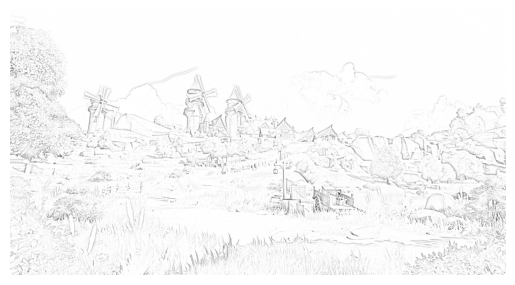

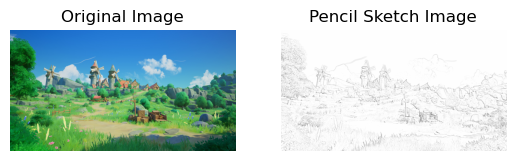

Pencil sketch image saved at: output-sketches\pencil_sketch_sample_image1.jpeg


In [6]:
if __name__ == "__main__":
    ## CLI verison
    main()
